In [39]:
import pandas as pd
df = pd.read_csv('/workspaces/SML/SML /train_v9rqX0R.csv')
df.head()
df.shape

(8523, 12)

In [40]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [41]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [42]:
#impute item_weight with mean
mean = df['Item_Weight'].mean()
df['Item_Weight'] = df['Item_Weight'].fillna(mean)

#impute Outlet_size with mode
mode = df['Outlet_Size'].mode()[0]
df['Outlet_Size'] = df['Outlet_Size'].fillna(mode)

In [43]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

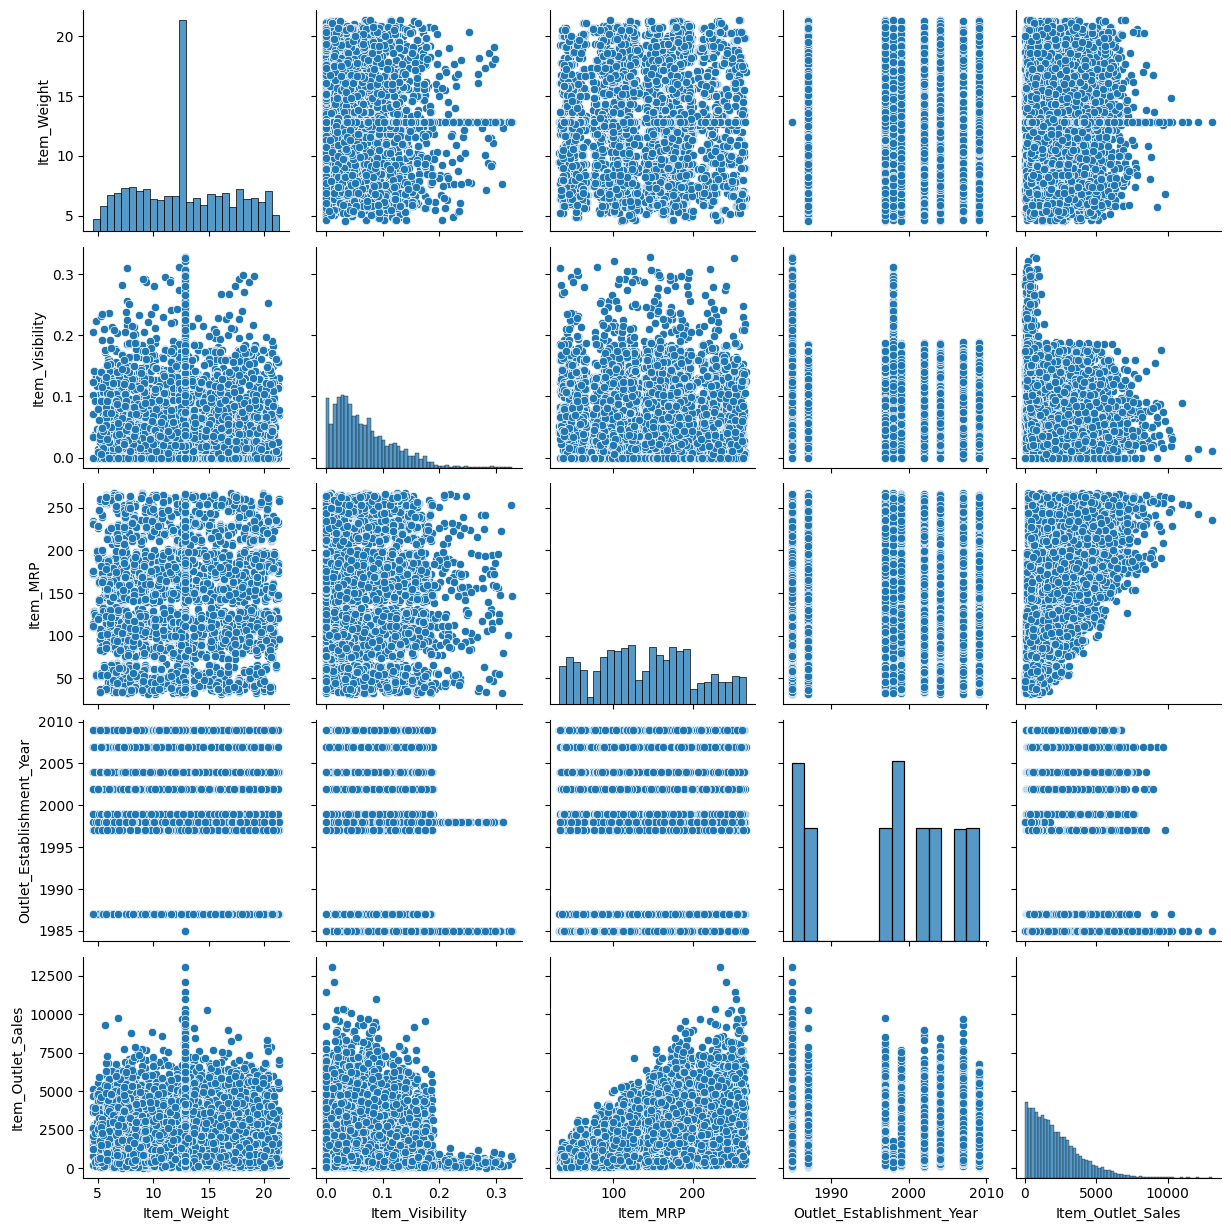

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df)
plt.show

In [45]:
df.drop(['Item_Identifier','Outlet_Identifier'],axis=1,inplace=True)
df = pd.get_dummies(df)

In [46]:
df.shape

(8523, 36)

In [47]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df,test_size=0.3)
x_train = train.drop('Item_Outlet_Sales',axis=1)
y_train = train['Item_Outlet_Sales']
x_test = test.drop('Item_Outlet_Sales',axis=1)
y_test = test['Item_Outlet_Sales']

In [48]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

x_train_scaled = scaler.fit_transform(x_train)
x_train = pd.DataFrame(x_train_scaled,columns=x_train.columns)

x_test_scaled = scaler.fit_transform(x_test)
x_test = pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [49]:
x_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 2557 entries, 0 to 2556
Data columns (total 35 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Item_Weight                      2557 non-null   float64
 1   Item_Visibility                  2557 non-null   float64
 2   Item_MRP                         2557 non-null   float64
 3   Outlet_Establishment_Year        2557 non-null   float64
 4   Item_Fat_Content_LF              2557 non-null   float64
 5   Item_Fat_Content_Low Fat         2557 non-null   float64
 6   Item_Fat_Content_Regular         2557 non-null   float64
 7   Item_Fat_Content_low fat         2557 non-null   float64
 8   Item_Fat_Content_reg             2557 non-null   float64
 9   Item_Type_Baking Goods           2557 non-null   float64
 10  Item_Type_Breads                 2557 non-null   float64
 11  Item_Type_Breakfast              2557 non-null   float64
 12  Item_Type_Canned               

In [50]:
from sklearn import neighbors
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt
%matplotlib inline

In [51]:
rmse_val = []
k_list = []
for K in range(50):
    K = K+1
    model = neighbors.KNeighborsRegressor(n_neighbors=K)

    model.fit(x_train,y_train)
    pred = model.predict(x_test)
    error = sqrt(mean_squared_error(y_test,pred))
    rmse_val.append(error)
    k_list.append(K)

    print("RMSE value for k =",K,"is",error)


RMSE value for k = 1 is 1584.5225698257364
RMSE value for k = 2 is 1361.4916078113936
RMSE value for k = 3 is 1298.1577762289753
RMSE value for k = 4 is 1256.7424062529308
RMSE value for k = 5 is 1235.327831992827
RMSE value for k = 6 is 1228.0740688096407
RMSE value for k = 7 is 1226.5423522397136
RMSE value for k = 8 is 1228.1104786496398
RMSE value for k = 9 is 1228.777561246284
RMSE value for k = 10 is 1225.6072354432301
RMSE value for k = 11 is 1224.3501824680518
RMSE value for k = 12 is 1228.835630845722
RMSE value for k = 13 is 1228.3547647132623
RMSE value for k = 14 is 1234.1445863652543
RMSE value for k = 15 is 1240.1157794836033
RMSE value for k = 16 is 1244.8512680517356
RMSE value for k = 17 is 1250.1593497521226
RMSE value for k = 18 is 1255.2227580554404
RMSE value for k = 19 is 1260.1718049529543
RMSE value for k = 20 is 1269.1611384059297
RMSE value for k = 21 is 1271.7332827714652
RMSE value for k = 22 is 1274.085847895033
RMSE value for k = 23 is 1276.798176743578
RM

RMSE value for k = 42 is 1296.0364981543717
RMSE value for k = 43 is 1294.462212874226
RMSE value for k = 44 is 1293.5053252218797
RMSE value for k = 45 is 1291.8250652978058
RMSE value for k = 46 is 1289.867324952203
RMSE value for k = 47 is 1287.5120032991267
RMSE value for k = 48 is 1286.8590790420471
RMSE value for k = 49 is 1284.7229434160322
RMSE value for k = 50 is 1283.3634089670395


In [52]:
best_rmse_score= min(rmse_val)
best_k = k_list[rmse_val.index(best_rmse_score)]
print("Optimum K value=",best_k,"with Score=",best_rmse_score)

Optimum K value= 11 with Score= 1224.3501824680518


<Axes: >

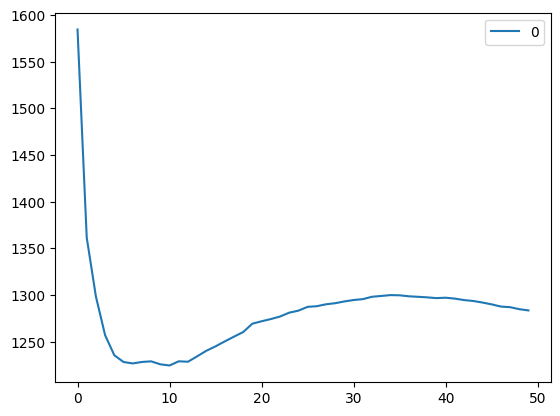

In [53]:
#ploting  the rmse values against k values
curve = pd.DataFrame(rmse_val) #elbow curve
curve.plot()